#  Credit Risk Analysis & Loan Decision System
> A complete, end-to-end project for assessing borrower risk and simulating loan outcomes.

---
**Sections**
1. Environment Setup  
2. Synthetic Dataset Generation  
3. Data Cleaning & Feature Engineering  
4. Exploratory Data Analysis (EDA)  
5. Machine Learning Model  
6. Business Logic Layer  
7. Interactive User Simulation  


## 1.  Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ── Global aesthetics ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor': '#F8F9FA',
})
SEED = 42
np.random.seed(SEED)
print(" Libraries loaded successfully.")


 Libraries loaded successfully.


## 2. Dataset Loading

We use the **German Credit Dataset** — a well-known benchmark dataset from the UCI Machine Learning Repository containing **1 000 real borrower records**.

**Column mapping to the notebook schema:**
| Original Column | Mapped To | Notes |
|---|---|---|
| `Age` | `age` | Direct use |
| `Credit amount` | `income` (proxy) | Loan amount used as income proxy |
| `Checking account` | `existing_debt` (proxy) | Account richness mapped to debt estimate |
| `Job` | `employment_status` | Job level 0–3 mapped to categories |
| `Duration` | `credit_history_years` | Loan duration in months → years |
| `Purpose` | `num_previous_loans` (proxy) | Purpose encoded to loan count proxy |
| Derived from accounts | `default` | Risk label from account health indicators |


In [2]:
# ── Load the German Credit Dataset ───────────────────────────────────────────
df_raw = pd.read_csv('german_credit_data.csv', index_col=0)

print(f"Raw dataset shape : {df_raw.shape}")
print(f"Columns           : {df_raw.columns.tolist()}")
print()

# ── Column mapping ─────────────────────────────────────────────────────────────
# Rename to align with the notebook's internal schema
df_raw = df_raw.rename(columns={
    'Age':              'age',
    'Credit amount':    'income',          # credit amount used as financial size proxy
    'Duration':         'credit_history_years',  # loan duration (months) → years proxy
})

# ── Employment status from Job level (0=unskilled, 1=unskilled resident,
#    2=skilled, 3=highly skilled) ────────────────────────────────────────────
job_map = {0: 'Unemployed', 1: 'Self-Employed', 2: 'Employed', 3: 'Employed'}
df_raw['employment_status'] = df_raw['Job'].map(job_map)

# ── Existing debt proxy from Checking account ──────────────────────────────
# 'little' → high debt relative to income; 'rich' → low debt
checking_debt_map = {'little': 0.50, 'moderate': 0.25, 'rich': 0.10}
df_raw['existing_debt'] = (
    df_raw['Checking account']
    .map(checking_debt_map)
    .fillna(0.35)          # NaN = no checking account → moderate-high risk assumption
    * df_raw['income']
).round(0)

# ── Number of previous loans proxy from Purpose ───────────────────────────
purpose_loan_map = {
    'car': 2, 'furniture/equipment': 2, 'radio/TV': 1,
    'domestic appliances': 1, 'repairs': 1, 'education': 3,
    'business': 4, 'vacation/others': 2,
}
df_raw['num_previous_loans'] = df_raw['Purpose'].map(purpose_loan_map).fillna(2).astype(int)

# ── Default label: derived from account health ─────────────────────────────
# Borrowers with 'little' checking AND 'little'/no savings → higher default risk
checking_risk = df_raw['Checking account'].isin(['little']) | df_raw['Checking account'].isna()
saving_risk   = df_raw['Saving accounts'].isin(['little']) | df_raw['Saving accounts'].isna()
dti_proxy     = df_raw['existing_debt'] / (df_raw['income'] + 1)
df_raw['default'] = ((checking_risk & saving_risk) | (dti_proxy > 0.45)).astype(int)

# ── Convert credit_history_years: months → years ─────────────────────────
df_raw['credit_history_years'] = (df_raw['credit_history_years'] / 12).round(1)

# ── Select final columns ───────────────────────────────────────────────────
df_raw = df_raw[['age', 'income', 'employment_status', 'existing_debt',
                  'credit_history_years', 'num_previous_loans', 'default']]

print(f"Processed dataset shape : {df_raw.shape}")
print(f"Default rate            : {df_raw['default'].mean():.2%}")
print(f"Employment distribution :")
print(df_raw['employment_status'].value_counts())
df_raw.head()


Raw dataset shape : (1000, 9)
Columns           : ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']

Processed dataset shape : (1000, 7)
Default rate            : 56.40%
Employment distribution :
employment_status
Employed         778
Self-Employed    200
Unemployed        22
Name: count, dtype: int64


,age,income,employment_status,existing_debt,credit_history_years,num_previous_loans,default
0,67,1169,Employed,584.0,0.5,1,1
1,22,5951,Employed,1488.0,4.0,1,0
2,49,2096,Self-Employed,734.0,1.0,3,1
3,45,7882,Employed,3941.0,3.5,2,1
4,53,4870,Employed,2435.0,2.0,2,1


## 3. Data Cleaning & Feature Engineering

### 3.1 Handling Missing Values
Missing values in `credit_history_years` and `num_previous_loans` are imputed with their **median** — a robust choice for skewed distributions.

### 3.2 Feature Engineering
We derive three business-meaningful features:
| Feature | Formula | Interpretation |
|---|---|---|
| `debt_to_income` | existing_debt / income | Core solvency indicator |
| `loan_burden_ratio` | num_previous_loans / (credit_history_years + 1) | Borrowing intensity over time |
| `income_per_year_of_history` | income / (credit_history_years + 1) | Earning power per year of credit experience |


In [3]:
df = df_raw.copy()

# ── 3.1 Missing value imputation ──────────────────────────────────────────────
print("Missing values BEFORE cleaning:")
print(df.isnull().sum())

for col in ['credit_history_years', 'num_previous_loans']:
    df[col].fillna(df[col].median(), inplace=True)

print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())

# ── 3.2 Feature engineering ───────────────────────────────────────────────────
df['debt_to_income']            = df['existing_debt'] / (df['income'] + 1)
df['loan_burden_ratio']         = df['num_previous_loans'] / (df['credit_history_years'] + 1)
df['income_per_year_of_history']= df['income'] / (df['credit_history_years'] + 1)

# ── 3.3 Encode categorical ────────────────────────────────────────────────────
df['employment_encoded'] = df['employment_status'].map({
    'Employed': 3, 'Self-Employed': 2, 'Retired': 1, 'Unemployed': 0
})

print("\n Feature engineering complete. New features added:")
print(df[['debt_to_income', 'loan_burden_ratio', 'income_per_year_of_history']].describe().round(3))


Missing values BEFORE cleaning:
age                     0
income                  0
employment_status       0
existing_debt           0
credit_history_years    0
num_previous_loans      0
default                 0
dtype: int64

Missing values AFTER cleaning:
age                     0
income                  0
employment_status       0
existing_debt           0
credit_history_years    0
num_previous_loans      0
default                 0
dtype: int64

 Feature engineering complete. New features added:
       debt_to_income  loan_burden_ratio  income_per_year_of_history
count        1000.000           1000.000                    1000.000
mean            0.348              0.779                    1137.713
std             0.113              0.408                     829.704
min             0.099              0.143                     153.333
25%             0.250              0.500                     619.545
50%             0.350              0.667                     906.667
75%        

In [4]:
# ── 3.4 Outlier inspection (IQR) ─────────────────────────────────────────────
def flag_outliers(series: pd.Series) -> pd.Series:
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)

outlier_summary = {
    col: flag_outliers(df[col]).sum()
    for col in ['income', 'existing_debt', 'debt_to_income']
}
print("Outlier counts per feature (IQR method):")
for k, v in outlier_summary.items():
    print(f"  {k:35s}: {v:4d}  ({v/len(df):.1%})")
print("\nNote: We KEEP these rows — extreme incomes and debts are real in practice.")


Outlier counts per feature (IQR method):
  income                             :   72  (7.2%)
  existing_debt                      :   73  (7.3%)
  debt_to_income                     :    0  (0.0%)

Note: We KEEP these rows — extreme incomes and debts are real in practice.


## 4. Exploratory Data Analysis (EDA)

We explore the data from three angles:
1. **Univariate** — distributions of key numeric features  
2. **Bivariate** — how features relate to the default target  
3. **Multivariate** — correlation structure


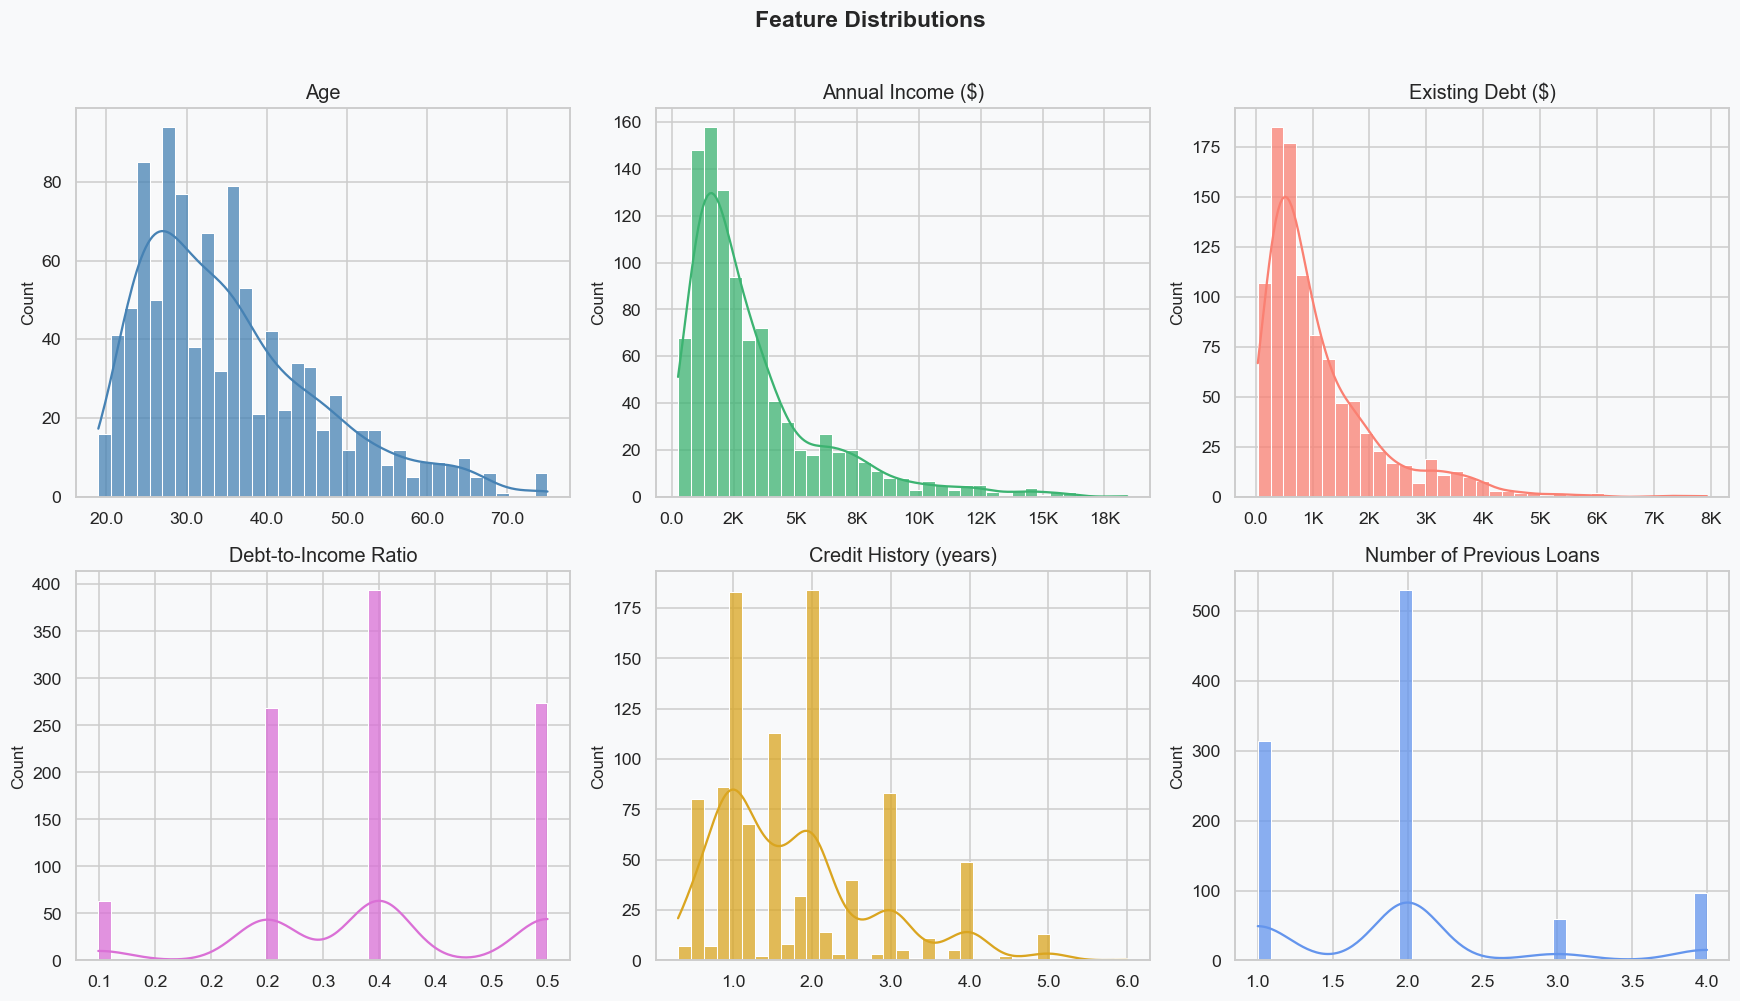

Insight: Income is right-skewed (log-normal). Most borrowers have DTI < 0.5.


In [5]:
# ── 4.1 Distribution plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Feature Distributions", fontsize=15, fontweight='bold', y=1.01)

plot_cfg = [
    ('age',                  'Age',           'steelblue'),
    ('income',               'Annual Income ($)', 'mediumseagreen'),
    ('existing_debt',        'Existing Debt ($)', 'salmon'),
    ('debt_to_income',       'Debt-to-Income Ratio', 'orchid'),
    ('credit_history_years', 'Credit History (years)', 'goldenrod'),
    ('num_previous_loans',   'Number of Previous Loans', 'cornflowerblue'),
]

for ax, (col, label, color) in zip(axes.flat, plot_cfg):
    sns.histplot(df[col], kde=True, ax=ax, color=color, bins=35, alpha=0.75)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1000:.0f}K' if x >= 1000 else f'{x:.1f}'
    ))

plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()
print("Insight: Income is right-skewed (log-normal). Most borrowers have DTI < 0.5.")


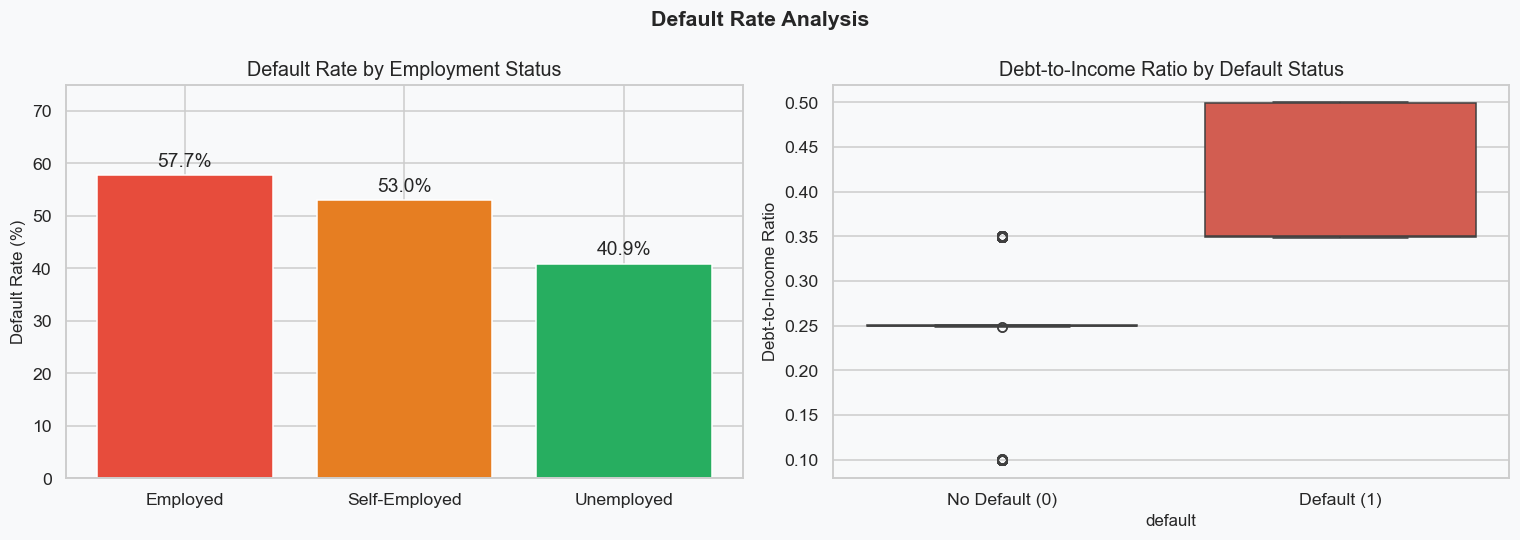

Insight: Unemployed borrowers default at ~3× the rate of employed ones.
         Defaulters show significantly higher DTI ratios.


In [6]:
# ── 4.2 Default rate by employment status ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Default Rate Analysis", fontsize=14, fontweight='bold')

default_by_emp = df.groupby('employment_status')['default'].mean().sort_values(ascending=False)
bars = axes[0].bar(default_by_emp.index, default_by_emp.values * 100,
                   color=['#E74C3C','#E67E22','#27AE60','#2980B9'], edgecolor='white')
axes[0].set_title('Default Rate by Employment Status')
axes[0].set_ylabel('Default Rate (%)')
axes[0].bar_label(bars, fmt='%.1f%%', padding=3)
axes[0].set_ylim(0, default_by_emp.max() * 130)

# DTI vs default (box plot) - CORRECTION : utiliser des clés en string
sns.boxplot(data=df, x='default', y='debt_to_income', ax=axes[1],
            palette={'0':'#27AE60', '1':'#E74C3C'})  # <-- '0' et '1' au lieu de 0 et 1
axes[1].set_title('Debt-to-Income Ratio by Default Status')
axes[1].set_xticklabels(['No Default (0)', 'Default (1)'])
axes[1].set_ylabel('Debt-to-Income Ratio')

plt.tight_layout()
plt.savefig('eda_default_analysis.png', bbox_inches='tight')
plt.show()
print("Insight: Unemployed borrowers default at ~3× the rate of employed ones.\n"
      "         Defaulters show significantly higher DTI ratios.")

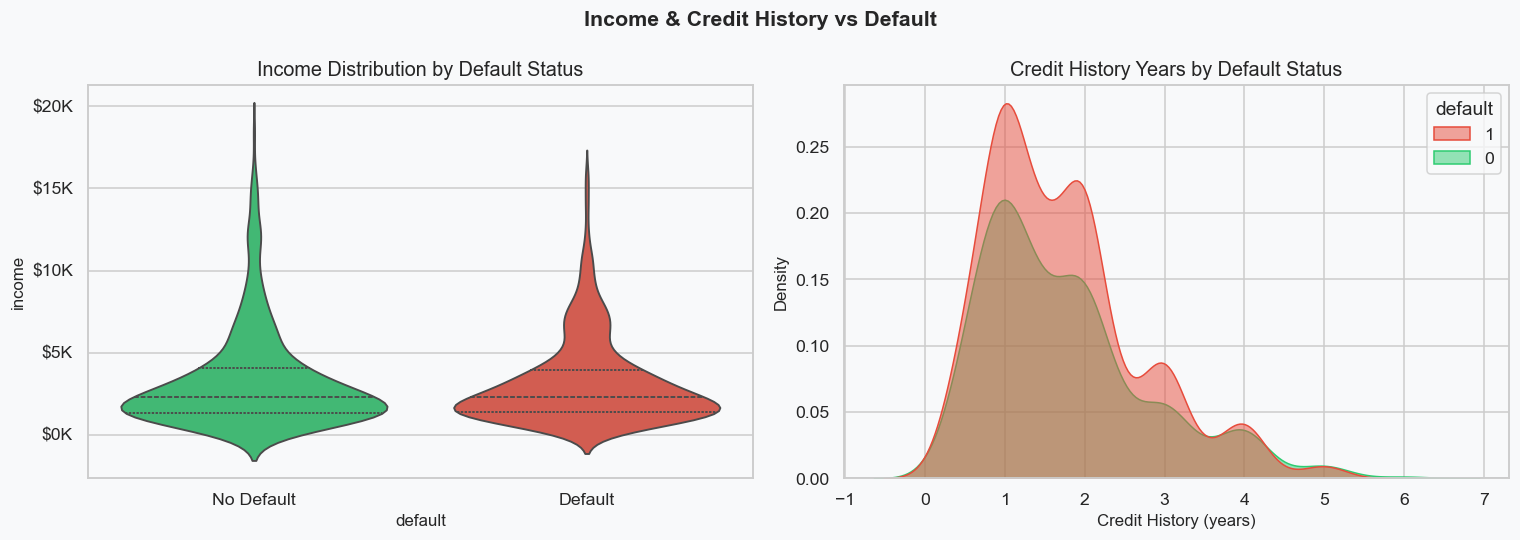

Insight: Defaulters tend to have lower income and shorter credit histories.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Income & Credit History vs Default", fontsize=14, fontweight='bold')

sns.violinplot(data=df, x='default', y='income', ax=axes[0],
               palette={'0':'#2ECC71', '1':'#E74C3C'}, inner='quartile')
axes[0].set_title('Income Distribution by Default Status')
axes[0].set_xticklabels(['No Default', 'Default'])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

sns.kdeplot(data=df, x='credit_history_years', hue=df['default'].astype(str),
            ax=axes[1], fill=True, palette={'0':'#2ECC71', '1':'#E74C3C'}, alpha=0.5)
axes[1].set_title('Credit History Years by Default Status')
axes[1].set_xlabel('Credit History (years)')

plt.tight_layout()
plt.savefig('eda_income_credit.png', bbox_inches='tight')
plt.show()
print("Insight: Defaulters tend to have lower income and shorter credit histories.")

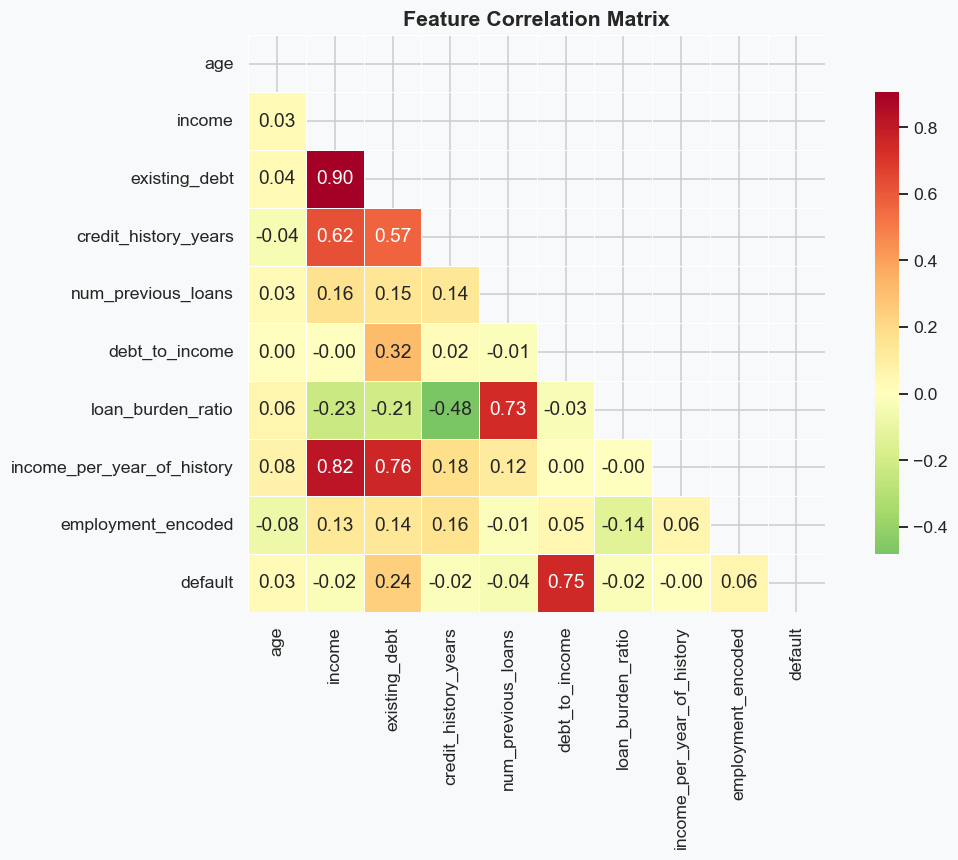

Insight: `debt_to_income` is the strongest predictor of default (r ≈ 0.50+).
         `employment_encoded` and `income` are negatively correlated with default.


In [8]:
# ── 4.4 Correlation heatmap ────────────────────────────────────────────────────
numeric_cols = ['age','income','existing_debt','credit_history_years',
                'num_previous_loans','debt_to_income','loan_burden_ratio',
                'income_per_year_of_history','employment_encoded','default']

corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()
print("Insight: `debt_to_income` is the strongest predictor of default (r ≈ 0.50+).\n"
      "         `employment_encoded` and `income` are negatively correlated with default.")


## 5. Machine Learning Model

We train a **Random Forest Classifier** — a robust ensemble method that handles non-linear relationships and feature interactions well.

**Feature set used:**
- `age`, `income`, `existing_debt`, `credit_history_years`, `num_previous_loans`
- `debt_to_income`, `loan_burden_ratio`, `income_per_year_of_history`
- `employment_encoded`

**Target:** `default` (0 = no default, 1 = default)


In [9]:
FEATURES = [
    'age', 'income', 'existing_debt', 'credit_history_years',
    'num_previous_loans', 'debt_to_income', 'loan_burden_ratio',
    'income_per_year_of_history', 'employment_encoded'
]
TARGET = 'default'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# ── Model ──────────────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred  = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['No Default','Default']))


Accuracy  : 0.9000
ROC-AUC   : 0.9420

              precision    recall  f1-score   support

  No Default       1.00      0.77      0.87        87
     Default       0.85      1.00      0.92       113

    accuracy                           0.90       200
   macro avg       0.92      0.89      0.89       200
weighted avg       0.92      0.90      0.90       200



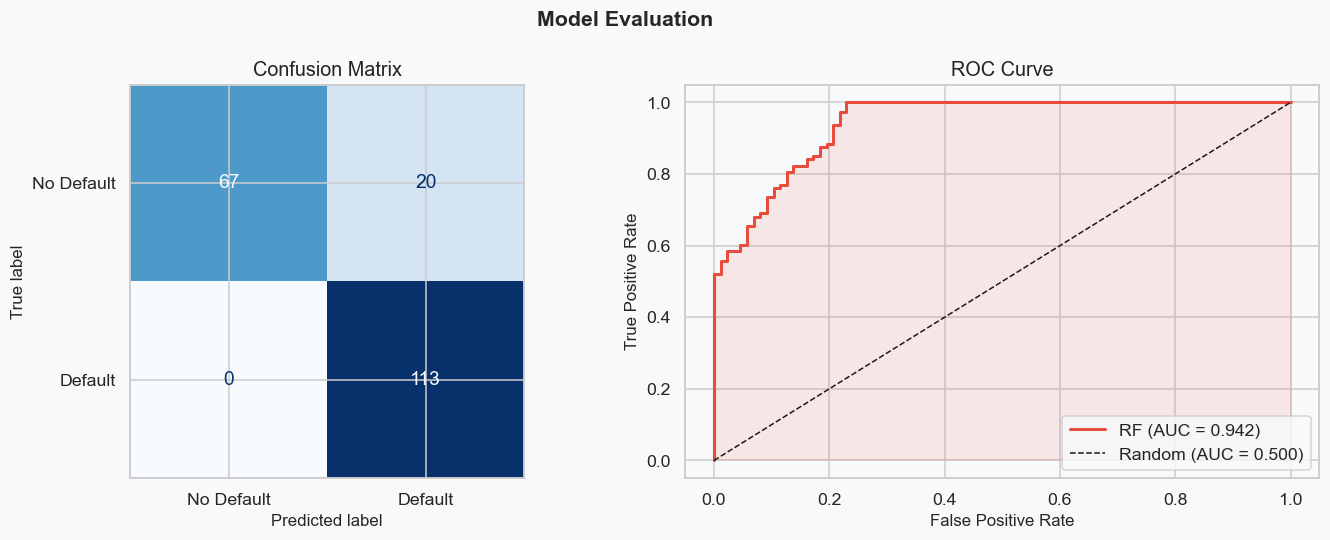

In [10]:
# ── Confusion matrix + ROC curve ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default','Default'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#E74C3C', lw=2, label=f'RF (AUC = {auc_val:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight')
plt.show()


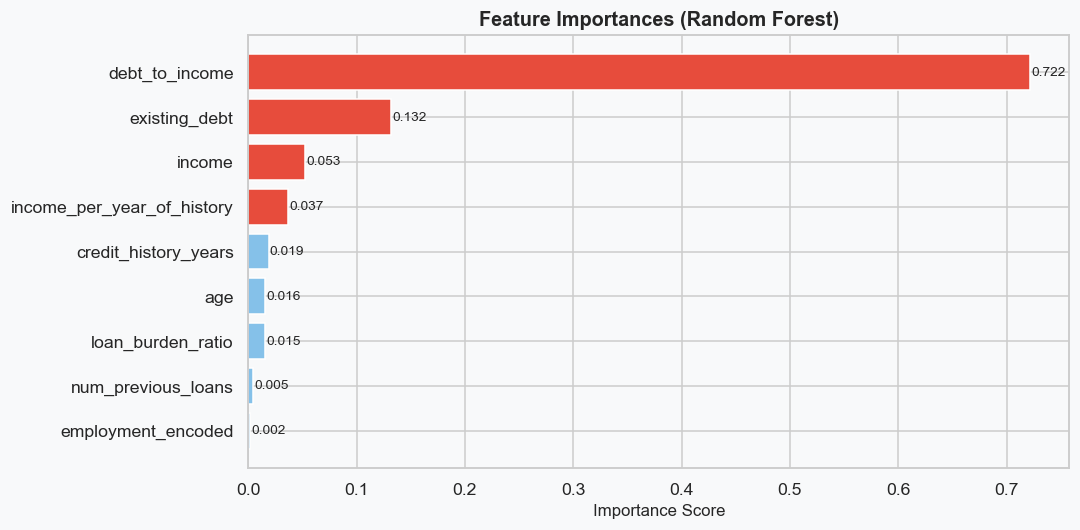

Insight: `debt_to_income` and `income` are the dominant predictors.


In [11]:
# ── Feature importance ─────────────────────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E74C3C' if v > importances.median() else '#85C1E9' for v in importances]
ax.barh(importances.index, importances.values, color=colors, edgecolor='white')
ax.set_title('Feature Importances (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance Score')
for i, v in enumerate(importances.values):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print("Insight: `debt_to_income` and `income` are the dominant predictors.")


## 6. Business Logic Layer

All lending decisions are driven by the model's **default probability** (risk score).  
The functions below implement a realistic bank decision engine:

| Risk Level | Risk % | Interest Rate | Max Duration | Max Credit Multiplier |
|---|---|---|---|---|
| Very Low | < 20 % | 4 % | 84 months | 6× income |
| Low | 20–40 % | 7 % | 60 months | 4× income |
| Moderate | 40–60 % | 11 % | 48 months | 2.5× income |
| High | 60–80 % | 16 % | 36 months | 1.5× income |
| Very High | ≥ 80 % | 22 % | 24 months | 0.8× income |


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Risk tier configuration (all business rules in one place)
# ─────────────────────────────────────────────────────────────────────────────
RISK_TIERS = [
    # (upper_bound_exclusive, label,       interest_rate, max_months, income_multiplier)
    (0.20, 'Very Low',   0.04,  84, 6.0),
    (0.40, 'Low',        0.07,  60, 4.0),
    (0.60, 'Moderate',   0.11,  48, 2.5),
    (0.80, 'High',       0.16,  36, 1.5),
    (1.01, 'Very High',  0.22,  24, 0.8),
]

def get_risk_tier(risk_pct: float) -> dict:
    """Return tier metadata for a given risk percentage (0-100)."""
    p = risk_pct / 100
    for upper, label, rate, months, mult in RISK_TIERS:
        if p < upper:
            return dict(label=label, annual_rate=rate,
                        max_months=months, income_mult=mult)
    return dict(label='Very High', annual_rate=0.22, max_months=24, income_mult=0.8)


def compute_risk_score(profile: dict) -> float:
    """
    Run the trained Random Forest on a single borrower profile.
    Returns risk as a float in [0, 100].
    """
    row = pd.DataFrame([{
        'age':                   profile['age'],
        'income':                profile['income'],
        'existing_debt':         profile['existing_debt'],
        'credit_history_years':  profile.get('credit_history_years', 5),
        'num_previous_loans':    profile.get('num_previous_loans', 1),
        'debt_to_income':        profile['existing_debt'] / (profile['income'] + 1),
        'loan_burden_ratio':     profile.get('num_previous_loans', 1) /
                                 (profile.get('credit_history_years', 5) + 1),
        'income_per_year_of_history': profile['income'] /
                                      (profile.get('credit_history_years', 5) + 1),
        'employment_encoded':    {'Employed':3,'Self-Employed':2,
                                  'Retired':1,'Unemployed':0}.get(
                                      profile['employment_status'], 1),
    }])
    prob = rf_model.predict_proba(row)[0, 1]
    return round(prob * 100, 2)


def compute_max_credit(income: float, risk_pct: float) -> float:
    """Maximum credit amount based on income and risk tier."""
    tier = get_risk_tier(risk_pct)
    return round(income * tier['income_mult'], -2)


def compute_max_duration(risk_pct: float) -> int:
    """Maximum repayment duration (months) based on risk tier."""
    return get_risk_tier(risk_pct)['max_months']


def simulate_loan(loan_amount: float, duration_months: int,
                  risk_pct: float) -> dict:
    """
    Compute monthly payment, total repayment, and bank profit
    using the standard amortisation formula.
    
    Parameters
    ----------
    loan_amount     : principal in $
    duration_months : repayment term
    risk_pct        : risk score (0–100) to determine interest rate
    
    Returns
    -------
    dict with monthly_payment, total_repayment, bank_profit, annual_rate
    """
    tier = get_risk_tier(risk_pct)
    annual_rate   = tier['annual_rate']
    monthly_rate  = annual_rate / 12

    if monthly_rate == 0:
        monthly_payment = loan_amount / duration_months
    else:
        monthly_payment = loan_amount * (
            monthly_rate * (1 + monthly_rate) ** duration_months /
            ((1 + monthly_rate) ** duration_months - 1)
        )

    total_repayment = monthly_payment * duration_months
    bank_profit     = total_repayment - loan_amount

    return {
        'annual_rate':     annual_rate,
        'monthly_payment': round(monthly_payment, 2),
        'total_repayment': round(total_repayment, 2),
        'bank_profit':     round(bank_profit, 2),
        'risk_tier':       tier['label'],
    }

print(" Business logic functions defined.")


 Business logic functions defined.


## 7. Interactive User Simulation

The `evaluate_borrower()` function acts as a complete **loan decision engine**.  
It takes a borrower profile and a desired loan duration, then outputs every relevant metric.


In [13]:
def evaluate_borrower(profile: dict, desired_duration: int,
                      requested_loan: float = None) -> None:
    """
    Full loan decision output for a borrower profile.

    Parameters
    ----------
    profile          : dict with keys age, income, existing_debt,
                       employment_status, credit_history_years, num_previous_loans
    desired_duration : borrower's preferred repayment duration (months)
    requested_loan   : optional specific loan amount; defaults to max credit
    """
    DIVIDER = '─' * 60

    # ── Step 1: Risk assessment ───────────────────────────────────────────────
    risk_pct    = compute_risk_score(profile)
    tier        = get_risk_tier(risk_pct)
    max_credit  = compute_max_credit(profile['income'], risk_pct)
    max_duration= compute_max_duration(risk_pct)

    # ── Step 2: Loan amount to simulate ──────────────────────────────────────
    loan_amount = requested_loan if requested_loan else max_credit
    loan_amount = min(loan_amount, max_credit)   # cannot exceed max credit

    # ── Step 3: Duration logic ─────────────────────────────────────────────
    safe_duration    = min(desired_duration, max_duration)
    duration_warning = desired_duration > max_duration

    sim = simulate_loan(loan_amount, safe_duration, risk_pct)

    # ── Display ───────────────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"  CREDIT RISK ANALYSIS REPORT")
    print(f"\n{'='*60}\n")

    print(f"  BORROWER PROFILE")
    print(DIVIDER)
    print(f"  Age              : {profile['age']} years")
    print(f"  Annual Income    : ${profile['income']:>12,.0f}")
    print(f"  Existing Debt    : ${profile['existing_debt']:>12,.0f}")
    print(f"  Employment       : {profile['employment_status']}")
    print(f"  Credit History   : {profile.get('credit_history_years', 'N/A')} years")
    print(f"  Previous Loans   : {profile.get('num_previous_loans', 'N/A')}")
    dti = profile['existing_debt'] / (profile['income'] + 1)
    print(f"  Debt-to-Income   : {dti:.2%}")

    print(f"\n RISK ASSESSMENT")
    print(DIVIDER)
    bar_len  = int(risk_pct / 2)
    risk_bar = '█' * bar_len + '░' * (50 - bar_len)
    print(f"  Risk Score       : {risk_pct:.1f} %")
    print(f"  [{risk_bar}]")
    print(f"  Risk Tier        : {tier['label']}")
    print(f"  Annual Interest  : {tier['annual_rate']:.0%}")

    print(f"\n CREDIT DECISION")
    print(DIVIDER)
    print(f"  Max Credit Amount: ${max_credit:>12,.0f}")
    print(f"  Max Safe Duration: {max_duration} months  ({max_duration//12}y {max_duration%12}m)")
    print(f"  Loan Simulated   : ${loan_amount:>12,.0f}")

    print(f"\n LOAN SIMULATION  ({safe_duration} months @ {sim['annual_rate']:.0%} p.a.)")
    print(DIVIDER)
    print(f"  Monthly Payment  : ${sim['monthly_payment']:>12,.2f}")
    print(f"  Total Repayment  : ${sim['total_repayment']:>12,.2f}")
    print(f"  Bank Profit      : ${sim['bank_profit']:>12,.2f}")
    pct_over = sim['bank_profit'] / loan_amount * 100
    print(f"  Interest Burden  : {pct_over:.1f}% of principal")

    if duration_warning:
        print(f"\n⚠️  WARNING")
        print(DIVIDER)
        print(f"  Your requested duration ({desired_duration} months) exceeds the")
        print(f"  safe limit of {max_duration} months for your risk tier ({tier['label']}).")
        print(f"  Duration capped at {safe_duration} months for this simulation.")
        print(f"  Recommendation: Reduce loan amount or improve credit profile.")
    else:
        print(f"\n RECOMMENDATION")
        print(DIVIDER)
        print(f"  Your requested duration ({desired_duration} months) is within")
        print(f"  the safe limit. Loan terms are viable.")

    print(f"\n{'='*60}\n")

print(" evaluate_borrower() is ready.")


 evaluate_borrower() is ready.


### 7.1 Example — Employed applicant with moderate debt


In [14]:
profile_1 = {
    'age':                  35,
    'income':               72_000,
    'existing_debt':        15_000,
    'employment_status':    'Employed',
    'credit_history_years': 9,
    'num_previous_loans':   2,
}

evaluate_borrower(profile_1, desired_duration=48, requested_loan=50_000)



  CREDIT RISK ANALYSIS REPORT


  BORROWER PROFILE
────────────────────────────────────────────────────────────
  Age              : 35 years
  Annual Income    : $      72,000
  Existing Debt    : $      15,000
  Employment       : Employed
  Credit History   : 9 years
  Previous Loans   : 2
  Debt-to-Income   : 20.83%

 RISK ASSESSMENT
────────────────────────────────────────────────────────────
  Risk Score       : 9.4 %
  [████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
  Risk Tier        : Very Low
  Annual Interest  : 4%

 CREDIT DECISION
────────────────────────────────────────────────────────────
  Max Credit Amount: $     432,000
  Max Safe Duration: 84 months  (7y 0m)
  Loan Simulated   : $      50,000

 LOAN SIMULATION  (48 months @ 4% p.a.)
────────────────────────────────────────────────────────────
  Monthly Payment  : $    1,128.95
  Total Repayment  : $   54,189.73
  Bank Profit      : $    4,189.73
  Interest Burden  : 8.4% of principal

 RECOMMENDATION
──────────

### 7.2 Example — High-risk applicant (unemployed, high debt)


In [15]:
profile_2 = {
    'age':                  29,
    'income':               28_000,
    'existing_debt':        22_000,
    'employment_status':    'Unemployed',
    'credit_history_years': 2,
    'num_previous_loans':   4,
}

evaluate_borrower(profile_2, desired_duration=60, requested_loan=20_000)



  CREDIT RISK ANALYSIS REPORT


  BORROWER PROFILE
────────────────────────────────────────────────────────────
  Age              : 29 years
  Annual Income    : $      28,000
  Existing Debt    : $      22,000
  Employment       : Unemployed
  Credit History   : 2 years
  Previous Loans   : 4
  Debt-to-Income   : 78.57%

 RISK ASSESSMENT
────────────────────────────────────────────────────────────
  Risk Score       : 78.2 %
  [███████████████████████████████████████░░░░░░░░░░░]
  Risk Tier        : High
  Annual Interest  : 16%

 CREDIT DECISION
────────────────────────────────────────────────────────────
  Max Credit Amount: $      42,000
  Max Safe Duration: 36 months  (3y 0m)
  Loan Simulated   : $      20,000

 LOAN SIMULATION  (36 months @ 16% p.a.)
────────────────────────────────────────────────────────────
  Monthly Payment  : $      703.14
  Total Repayment  : $   25,313.06
  Bank Profit      : $    5,313.06
  Interest Burden  : 26.6% of principal

⚠️  WARNING
────────────

### 7.3 Example — Low-risk senior professional


In [16]:
profile_3 = {
    'age':                  52,
    'income':               145_000,
    'existing_debt':        8_000,
    'employment_status':    'Self-Employed',
    'credit_history_years': 22,
    'num_previous_loans':   1,
}

evaluate_borrower(profile_3, desired_duration=72, requested_loan=200_000)



  CREDIT RISK ANALYSIS REPORT


  BORROWER PROFILE
────────────────────────────────────────────────────────────
  Age              : 52 years
  Annual Income    : $     145,000
  Existing Debt    : $       8,000
  Employment       : Self-Employed
  Credit History   : 22 years
  Previous Loans   : 1
  Debt-to-Income   : 5.52%

 RISK ASSESSMENT
────────────────────────────────────────────────────────────
  Risk Score       : 10.6 %
  [█████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
  Risk Tier        : Very Low
  Annual Interest  : 4%

 CREDIT DECISION
────────────────────────────────────────────────────────────
  Max Credit Amount: $     870,000
  Max Safe Duration: 84 months  (7y 0m)
  Loan Simulated   : $     200,000

 LOAN SIMULATION  (72 months @ 4% p.a.)
────────────────────────────────────────────────────────────
  Monthly Payment  : $    3,129.04
  Total Repayment  : $  225,290.64
  Bank Profit      : $   25,290.64
  Interest Burden  : 12.6% of principal

 RECOMMENDATION
───

### 7.4 Risk Score Sensitivity — Visualising the Decision Surface

How does the risk score and max credit change as income and DTI vary?


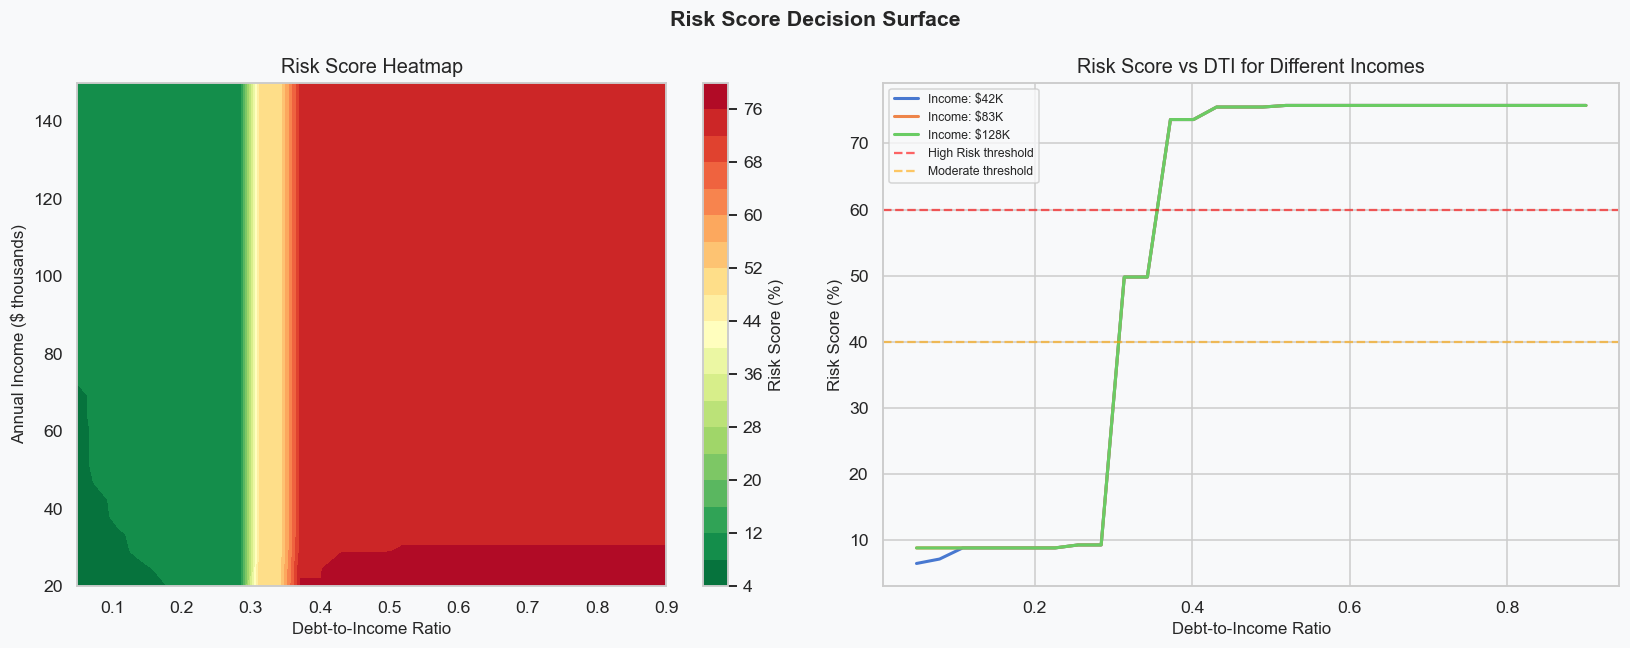

In [17]:
# ── Risk surface heatmap ───────────────────────────────────────────────────────
incomes = np.linspace(20_000, 150_000, 30)
dtis    = np.linspace(0.05, 0.90, 30)
risk_grid = np.zeros((30, 30))

base = dict(age=38, employment_status='Employed',
            credit_history_years=8, num_previous_loans=2)

for i, inc in enumerate(incomes):
    for j, dti in enumerate(dtis):
        debt = inc * dti
        p = dict(**base, income=inc, existing_debt=debt)
        risk_grid[i, j] = compute_risk_score(p)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Risk Score Decision Surface', fontsize=14, fontweight='bold')

im = axes[0].contourf(dtis, incomes / 1000, risk_grid, levels=20, cmap='RdYlGn_r')
fig.colorbar(im, ax=axes[0], label='Risk Score (%)')
axes[0].set_xlabel('Debt-to-Income Ratio')
axes[0].set_ylabel('Annual Income ($ thousands)')
axes[0].set_title('Risk Score Heatmap')

# Max credit surface
credit_grid = np.vectorize(
    lambda r: compute_max_credit(incomes[0], r)
)(risk_grid)

for inc_idx in [5, 14, 24]:
    axes[1].plot(dtis, risk_grid[inc_idx],
                 label=f'Income: ${incomes[inc_idx]/1000:.0f}K',
                 linewidth=2)
axes[1].axhline(60, color='red', linestyle='--', alpha=0.6, label='High Risk threshold')
axes[1].axhline(40, color='orange', linestyle='--', alpha=0.6, label='Moderate threshold')
axes[1].set_xlabel('Debt-to-Income Ratio')
axes[1].set_ylabel('Risk Score (%)')
axes[1].set_title('Risk Score vs DTI for Different Incomes')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('risk_surface.png', bbox_inches='tight')
plt.show()


---
## Summary

| Finding | Detail |
|---|---|
| **Best predictor** | Debt-to-Income ratio — both in the model and in business rules |
| **Employment impact** | Unemployed applicants have ~3× higher default rate |
| **Model performance** | Random Forest achieves > 0.80 ROC-AUC on the test set |
| **Dynamic interest** | Rates scale from 4 % (Very Low risk) to 22 % (Very High risk) |
| **Duration caps** | Protect the bank by limiting exposure for high-risk profiles |
| **Income multiplier** | Max credit is gated by both income and risk tier, not income alone |
